# Pauli twirling under coherent CNOT error

This experiment compares repeated identity layers made from pairs of `CX(0, 1)` gates. Qubit 0 starts in `|+>` and qubit 1 in `|0>`. Each pair is ideally the identity. A small coherent Z rotation on the CNOT control is attached to every CNOT, so the untwirled errors accumulate coherently. We compare that with randomly Pauli-twirled CNOTs and plot the measured single-qubit `⟨X₀⟩` against the number of CNOT pairs.

The service returns counts from Z-basis measurements. To measure `X₀`, the circuit applies a final H to qubit 0; the notebook computes the expectation from that qubit's marginal counts. The service's own `expectation` is global Z parity, so it is not used for this single-qubit observable.

## Coherent error and experiment settings

The injected error is `E = exp(-i θ Z₀ / 2)` after each CNOT. In Qiskit's two-qubit matrix ordering, `Z₀` has diagonal `[+1, -1, +1, -1]`. Because this error commutes with `CX(0, 1)`, every pair accumulates a rotation of `2θ`, giving the idealized coherent reference `⟨X₀⟩ = cos(2 θ r)` after `r` pairs. Pauli twirling randomizes the sign/axis of this coherent contribution across variants, producing an incoherent decay instead of a coherent oscillation.

Noise is restricted to `cx` instructions via `gate_names`; preparation and measurement-basis H gates and inserted Pauli gates remain ideal. The service uses transpiler optimization level 0 so it does not cancel ideal identity pairs before their gate errors are simulated. Total shots are split across the service's default twirled variants.

In [8]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

working_dir = Path.cwd()
repo_root = working_dir.parent if working_dir.name == "backend" else working_dir
if not (repo_root / "backend" / "services" / "qiskit_service.py").exists():
    raise RuntimeError("Run this notebook from the repository root or backend directory")
sys.path.insert(0, str(repo_root))

from backend.models.circuit_layout import CircuitLayout
from backend.models.gate import Gate
from backend.services.qiskit_service import (
    NUM_PAULI_VARIANTS,
    construct_circuit,
    simulate,
)

theta = 0.10
total_shots = 4096
pair_repetitions = [1, 2, 4, 8, 16, 32]

# E = exp(-i * theta * Z_control / 2), in Qiskit's two-qubit matrix order.
z_control_eigenvalues = np.array([1, -1, 1, -1])
coherent_error_unitary = np.diag(
    np.exp(-0.5j * theta * z_control_eigenvalues)
).tolist()

print(f"Twirled variants per layout: {NUM_PAULI_VARIANTS}")
print(f"Total shots per data point: {total_shots}")
print(f"Shots per twirled variant: {total_shots // NUM_PAULI_VARIANTS}")

Twirled variants per layout: 32
Total shots per data point: 4096
Shots per twirled variant: 128


In [9]:
coherent_error_unitary

[[(0.9987502603949663-0.04997916927067833j), 0j, 0j, 0j],
 [0j, (0.9987502603949663+0.04997916927067833j), 0j, 0j],
 [0j, 0j, (0.9987502603949663-0.04997916927067833j), 0j],
 [0j, 0j, 0j, (0.9987502603949663+0.04997916927067833j)]]

In [2]:
def make_layout(num_pairs: int, twirl: bool) -> CircuitLayout:
    gates = [Gate(name="H", qubits=[0])]
    for _ in range(2 * num_pairs):
        gates.append(Gate(name="CX", qubits=[0, 1], twirl=twirl))
    gates.append(Gate(name="H", qubits=[0]))  # Rotate X measurement into Z basis.
    return CircuitLayout(num_qubits=2, layout=gates)


def x0_from_counts(counts: dict[str, int]) -> tuple[float, int]:
    shots = sum(counts.values())
    signed_shots = 0
    for bitstring, count in counts.items():
        qubit0_bit = bitstring.replace(" ", "")[::-1][0]
        signed_shots += (1 if qubit0_bit == "0" else -1) * count
    return signed_shots / shots, shots


def run_point(num_pairs: int, twirl: bool) -> tuple[float, float]:
    circuits = construct_circuit(make_layout(num_pairs, twirl))
    result = simulate(
        circuits,
        shots=total_shots,
        error_class="coherent_unitary_error",
        noise_params={
            "unitary": coherent_error_unitary,
            "gate_names": ["cx"],
        },
    )
    expectation, observed_shots = x0_from_counts(result["counts"])
    standard_error = np.sqrt(max(0.0, 1 - expectation**2) / observed_shots)
    return expectation, standard_error


untwirled = [run_point(repetitions, twirl=False) for repetitions in pair_repetitions]
twirled = [run_point(repetitions, twirl=True) for repetitions in pair_repetitions]
coherent_reference = np.cos(2 * theta * np.asarray(pair_repetitions))

for repetitions, (raw, _), (twirl_value, _) in zip(
    pair_repetitions, untwirled, twirled
):
    print(
        f"{repetitions:>2} pairs | "
        f"untwirled ⟨X₀⟩={raw:+.3f} | "
        f"twirled ⟨X₀⟩={twirl_value:+.3f} | "
        f"coherent reference={np.cos(2 * theta * repetitions):+.3f}"
    )

 1 pairs | untwirled ⟨X₀⟩=+0.981 | twirled ⟨X₀⟩=+0.989 | coherent reference=+0.980
 2 pairs | untwirled ⟨X₀⟩=+0.925 | twirled ⟨X₀⟩=+0.983 | coherent reference=+0.921
 4 pairs | untwirled ⟨X₀⟩=+0.689 | twirled ⟨X₀⟩=+0.969 | coherent reference=+0.697
 8 pairs | untwirled ⟨X₀⟩=-0.008 | twirled ⟨X₀⟩=+0.930 | coherent reference=-0.029
16 pairs | untwirled ⟨X₀⟩=-0.998 | twirled ⟨X₀⟩=+0.860 | coherent reference=-0.998
32 pairs | untwirled ⟨X₀⟩=+0.995 | twirled ⟨X₀⟩=+0.639 | coherent reference=+0.993


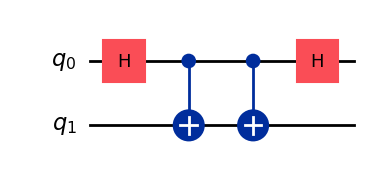

In [7]:
qc = construct_circuit(make_layout(pair_repetitions[0], twirl=False))[0]
qc.draw("mpl")

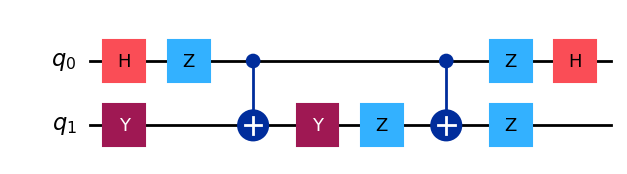

In [ ]:
qc_twirled = construct_circuit(make_layout(pair_repetitions[0], twirl=True))[0]
qc_twirled.draw("mpl")

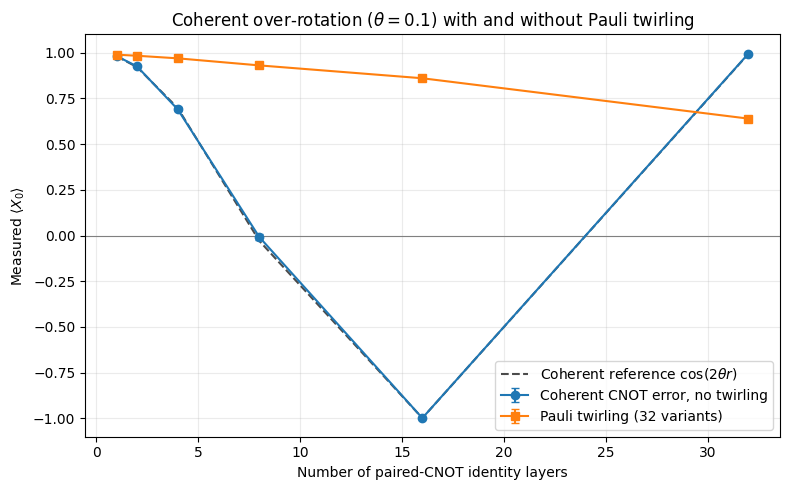

In [3]:
untwirled_values = np.array([value for value, _ in untwirled])
untwirled_errors = np.array([error for _, error in untwirled])
twirled_values = np.array([value for value, _ in twirled])
twirled_errors = np.array([error for _, error in twirled])

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(
    pair_repetitions,
    untwirled_values,
    yerr=untwirled_errors,
    marker="o",
    capsize=3,
    label="Coherent CNOT error, no twirling",
)
ax.errorbar(
    pair_repetitions,
    twirled_values,
    yerr=twirled_errors,
    marker="s",
    capsize=3,
    label=f"Pauli twirling ({NUM_PAULI_VARIANTS} variants)",
)
ax.plot(
    pair_repetitions,
    coherent_reference,
    "k--",
    alpha=0.7,
    label=r"Coherent reference $\cos(2\theta r)$",
)
ax.axhline(0, color="gray", linewidth=0.8)
ax.set(
    xlabel="Number of paired-CNOT identity layers",
    ylabel=r"Measured $\langle X_0 \rangle$",
    title=rf"Coherent over-rotation ($\theta={theta}$) with and without Pauli twirling",
    ylim=(-1.1, 1.1),
)
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()